In [12]:
import os
import random
import cv2
import numpy as np

input_dir = 'Agricultural_Image_Analytics/leaves'
output_dir = 'Augmented'

os.makedirs(output_dir, exist_ok=True)

source_images = [f"I{i}.png" for i in range(1, 9)]
source_image_paths = [os.path.join(input_dir, f) for f in source_images]

for i in range(100):
    source_path = random.choice(source_image_paths)
    source_filename = os.path.basename(source_path)
    
    img = cv2.imread(source_path)
    h, w = img.shape[:2]
    batch_idx = i // 25  
    
    if batch_idx == 0:
        # ROTATE (0 to 360 degrees) 
        angle = random.uniform(0, 360)
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, scale=1.0)
        aug_img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        prefix = "rotate"
        
    elif batch_idx == 1:
        # SHIFT (Up to 50% of width/height)
        tx = random.uniform(-w * 0.5, w * 0.5)
        ty = random.uniform(-h * 0.5, h * 0.5)
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        aug_img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        prefix = "shift"
        
    elif batch_idx == 2:
        # SCALE (0.5x to 2.0x)
        scale = random.uniform(0.5, 2.0)
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle=0, scale=scale)
        aug_img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        prefix = "scale"
        
    else:
        # WARP (Up to 25% distortion on corners)
        src_points = np.float32([[0, 0], [w-1, 0], [0, h-1], [w-1, h-1]])
        dx = w * 0.25
        dy = h * 0.25
        dst_points = np.float32([
            [random.uniform(0, dx), random.uniform(0, dy)], 
            [w-1 - random.uniform(0, dx), random.uniform(0, dy)], 
            [random.uniform(0, dx), h-1 - random.uniform(0, dy)], 
            [w-1 - random.uniform(0, dx), h-1 - random.uniform(0, dy)]
        ])
        M = cv2.getPerspectiveTransform(src_points, dst_points)
        aug_img = cv2.warpPerspective(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        prefix = "warp"

    new_filename = f"{prefix}_{i+1:03d}_from_{source_filename}"
    output_path = os.path.join(output_dir, new_filename)
    cv2.imwrite(output_path, aug_img)

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.image import extract_patches_2d

# --- Task 2: Extract Local Patches ---
all_patches = []
# Ensure output_dir is defined from your previous steps
for filename in [f for f in os.listdir(output_dir) if f.endswith('.png')]:
    img = cv2.imread(os.path.join(output_dir, filename))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    patches = extract_patches_2d(img, patch_size=(32, 32), max_patches=10)
    all_patches.append(patches)

X = np.array(all_patches).reshape(-1, 32 * 32 * 3) 
X_original = X.copy()

# --- Task 3: ZCA Whitening ---
def zca_whitening(X):
    # 1. Zero-centering (UFLDL Step 0b)
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean
    
    # 2. Covariance
    sigma = np.dot(X_centered.T, X_centered) / X_centered.shape[0]
    
    # 3. SVD
    U, S, V = np.linalg.svd(sigma)
    
    # 4. ZCA Transform Math (UFLDL Step 4 & 5)
    epsilon = 0.1 
    # PCA Whitening
    xPCAwhite = np.dot(X_centered, np.dot(U, np.diag(1.0 / np.sqrt(S + epsilon))))
    # ZCA Whitening (Rotating back to pixel space)
    X_ZCA = np.dot(xPCAwhite, U.T)
    
    return X_ZCA

X_white = zca_whitening(X)


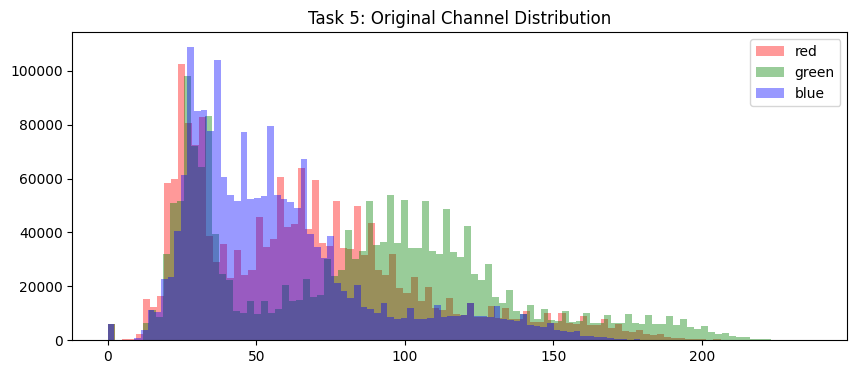

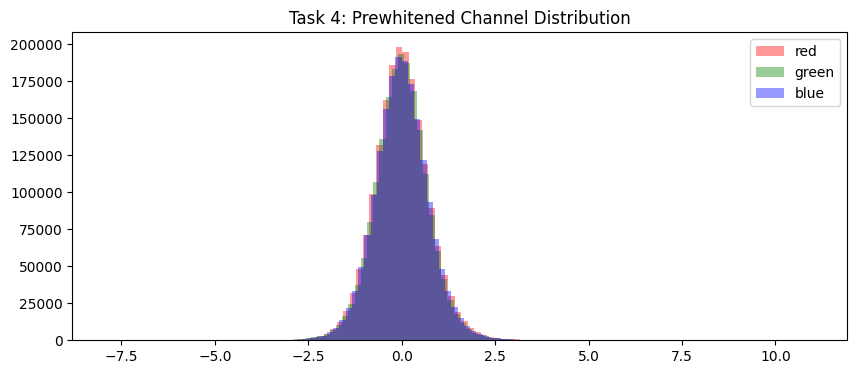

In [17]:

# --- Task 4 & 5: Display Distributions ---
def plot_dist(data, title):
    # Reshape back to images to get R, G, B channels
    data_img = data.reshape(-1, 32, 32, 3)
    plt.figure(figsize=(10, 4))
    for i, col in enumerate(['red', 'green', 'blue']):
        plt.hist(data_img[:,:,:,i].flatten(), bins=100, color=col, alpha=0.4, label=col)
    plt.title(title)
    plt.legend()
    plt.show()

plot_dist(X_original, "Task 5: Original Channel Distribution")
plot_dist(X_white, "Task 4: Prewhitened Channel Distribution")

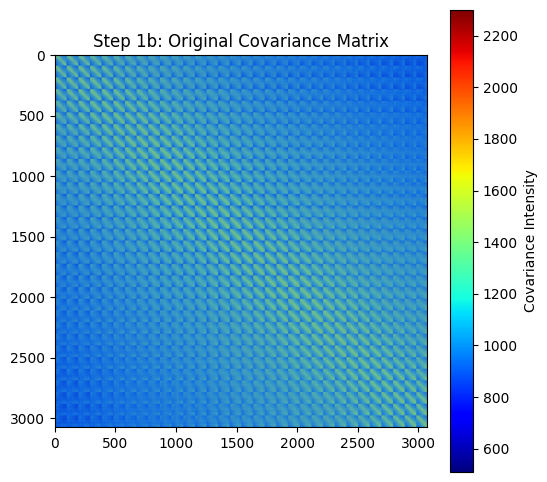

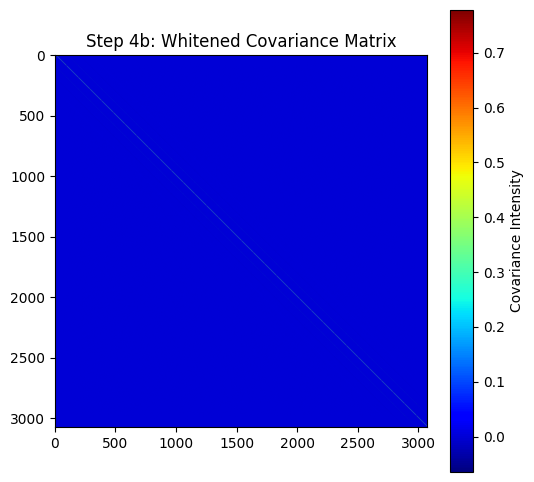

In [21]:
def visualize_covariance(data, title):
    # Calculate covariance matrix
    cov = np.cov(data, rowvar=False)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(cov, cmap='jet')
    plt.title(title)
    plt.colorbar(label='Covariance Intensity')
    plt.show()

visualize_covariance(X_original, "Step 1b: Original Covariance Matrix")
visualize_covariance(X_white, "Step 4b: Whitened Covariance Matrix")

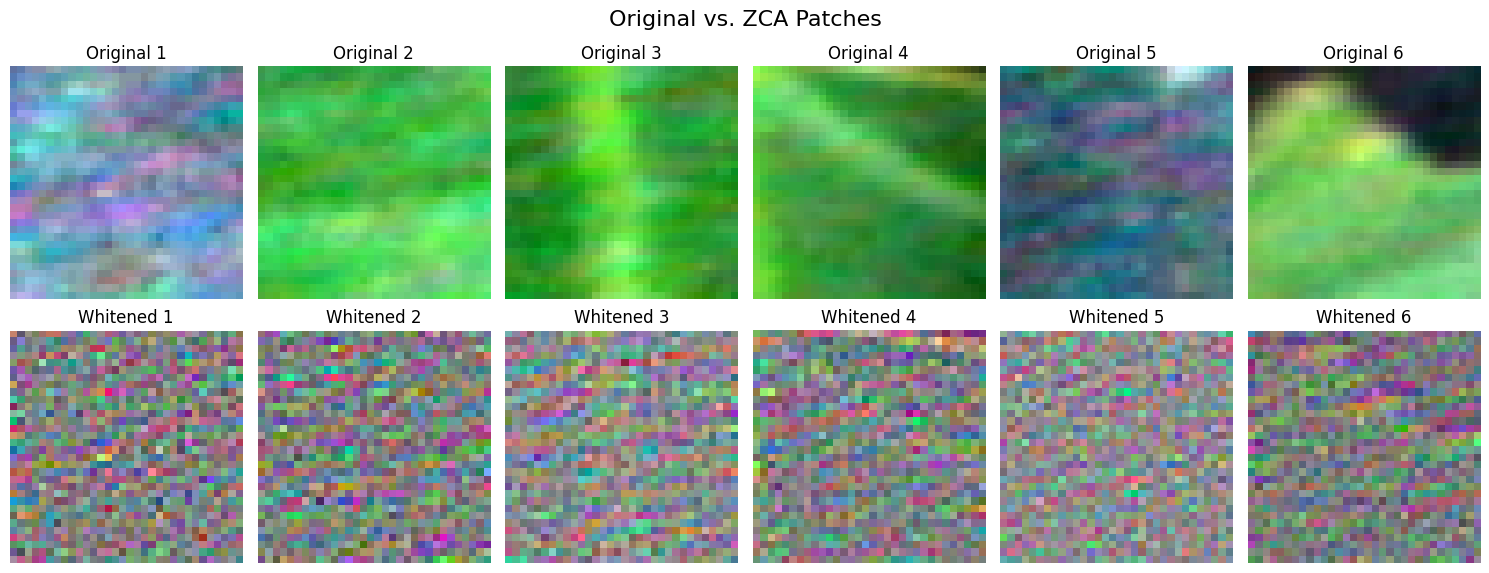

In [22]:
import matplotlib.pyplot as plt

def plot_6_comparison(original_data, whitened_data):
    orig_imgs = original_data.reshape(-1, 32, 32, 3)
    white_imgs = whitened_data.reshape(-1, 32, 32, 3)
    
    
    fig, axes = plt.subplots(2, 6, figsize=(15, 6))
    
    for i in range(6):
        img_o = orig_imgs[i]
        # Normalize
        img_o_norm = (img_o - img_o.min()) / (img_o.max() - img_o.min())
        
        axes[0, i].imshow(img_o_norm)
        axes[0, i].set_title(f"Original {i+1}")
        axes[0, i].axis('off')
        
        img_w = white_imgs[i]
        # Normalize
        img_w_norm = (img_w - img_w.min()) / (img_w.max() - img_w.min())
        
        axes[1, i].imshow(img_w_norm)
        axes[1, i].set_title(f"Whitened {i+1}")
        axes[1, i].axis('off')

    plt.suptitle("Original vs. ZCA Patches", fontsize=16)
    plt.tight_layout()
    plt.show()

# Execute the visualization
plot_6_comparison(X_original, X_white)

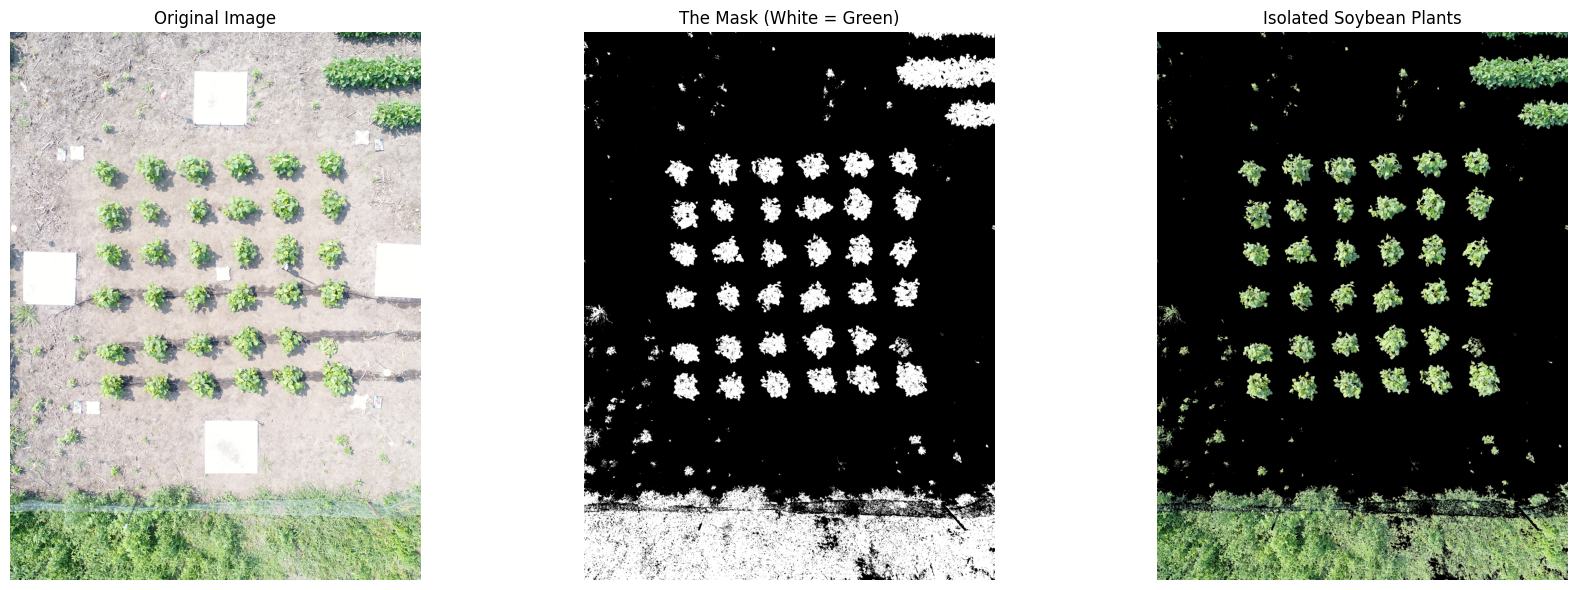

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load your image
image_path = 'Agricultural_Image_Analytics/2.JPG' # Make sure this path is correct!
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Convert to HSV color space
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])

# 4. Create the Mask (White = In Range, Black = Out of Range)
mask = cv2.inRange(hsv, lower_green, upper_green)

# 5. Apply the mask to the original image so we can see the isolated plants
result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

# --- Plot Before & After ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title("The Mask (White = Green)")
axes[1].axis('off')

axes[2].imshow(result)
axes[2].set_title("Isolated Soybean Plants")
axes[2].axis('off')

plt.tight_layout()
plt.show()

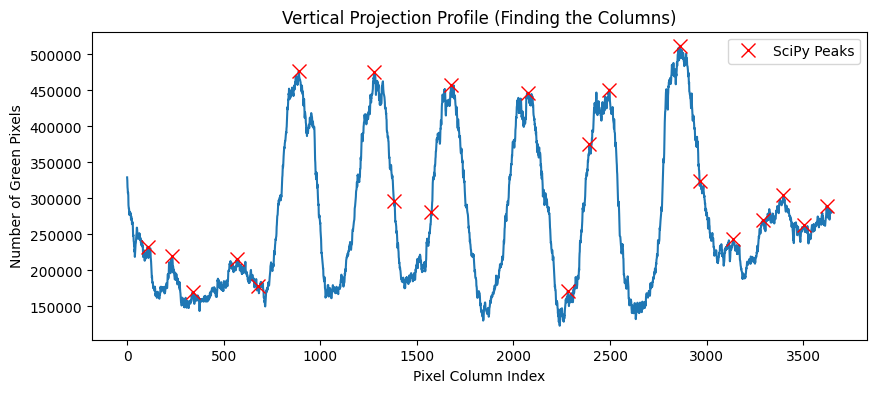

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Assuming 'mask' is your binary image from the HSV thresholding step
# where plants are 255 (or 1) and dirt is 0.

# 1. "Squash" the image to get the 1D profiles
row_profile = np.sum(mask, axis=1) # Sum across columns for each row
col_profile = np.sum(mask, axis=0) # Sum down rows for each column

# 2. Use SciPy to find the peaks (maxima intensity)
# distance dictates the minimum number of pixels between peaks 
# (prevents finding multiple peaks on the same plant)
row_peaks, _ = find_peaks(row_profile, distance=100, prominence=5000)
col_peaks, _ = find_peaks(col_profile, distance=100, prominence=5000)

# Let's plot the column profile to see what SciPy is looking at
plt.figure(figsize=(10, 4))
plt.plot(col_profile)
plt.plot(col_peaks, col_profile[col_peaks], "x", color='red', markersize=10, label="SciPy Peaks")
plt.title("Vertical Projection Profile (Finding the Columns)")
plt.xlabel("Pixel Column Index")
plt.ylabel("Number of Green Pixels")
plt.legend()
plt.show()